# Figure 2H-I - Rest V Run - Groupwise

In [1]:
import seaborn as sb
import pingouin as pg
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('paper_style.mplstyle')

savepath='/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure2-Supp3/plots'

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# FC MICE

In [2]:
deciles_rest = pd.read_csv('rate_rest_deciles_all.csv')
deciles_rest = deciles_rest.query("Group=='FC'")
deciles_run = pd.read_csv('rate_run_deciles_all.csv')
deciles_run = deciles_run.query("Group=='FC'")

## Figure 2H Stats

In [3]:
Y = [np.mean(deciles_rest['P(Tagged)'].loc[deciles_rest['Deciles']==d].values) for d in np.arange(1,11)]
X = np.arange(0,10)
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results_rest = model.fit()

pred_ols_rest = results_rest.get_prediction()
ci_low_rest = pred_ols_rest.summary_frame()["mean_ci_lower"]
ci_hi_rest = pred_ols_rest.summary_frame()["mean_ci_upper"]
rsq_rest=results_rest.rsquared
pval_rest=results_rest.pvalues[1]
results_rest.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     9.401
Date:                Mon, 04 May 2026   Prob (F-statistic):             0.0154
Time:                        15:01:10   Log-Likelihood:                 17.008
No. Observations:                  10   AIC:                            -30.02
Df Residuals:                       8   BIC:                            -29.41
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2588      0.029      8.916      0.000       0.192       0.326
x1             0.0167      0.005      3.066      0.015       0.004       0.029
==============================================================================
Omnibus:                        2.641   Durbin-Watson:                   2.356
Prob(Omnibus):                  0.267   Jarque-Bera (JB):                0.918
Skew:                          -0.013   Prob(JB):                        0.632
Kurtosis:                       1.516   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

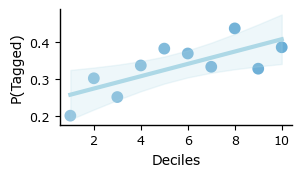

In [4]:
fig,ax=plt.subplots(figsize=(3,1.5))
cmap = mpl.cm.get_cmap('Blues')
colors = np.linspace(.4,.5,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':3,'s':30},ax=ax)
ax.plot(np.arange(1,11),results_rest.fittedvalues,'lightblue',linewidth=3,linestyle='-')
# ax.plot(np.arange(1,11),ci_low_run,'--',color='gray',linewidth=2,alpha=.5)
# ax.plot(np.arange(1,11),ci_hi_run,'--',color='gray',linewidth=2,alpha=.5)
ax.fill_between(np.arange(1,11), ci_low_rest, ci_hi_rest, color='lightblue', alpha=0.2, label='Error Band')  # Error band
sb.despine()
#plt.savefig('rest_fc_avmice_regline.svg',transparent=True)

In [5]:
Y = [np.mean(deciles_run['P(Tagged)'].loc[deciles_run['Deciles']==d].values) for d in np.arange(1,11)]
X = np.arange(0,10)
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results_run = model.fit()

pred_ols = results_run.get_prediction()
ci_low_run = pred_ols.summary_frame()["mean_ci_lower"]
ci_hi_run = pred_ols.summary_frame()["mean_ci_upper"]
rsq_run=results_run.rsquared
pval_run=results_run.pvalues[1]
results_run.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.9611
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.356
Time:                        15:01:10   Log-Likelihood:                 16.438
No. Observations:                  10   AIC:                            -28.88
Df Residuals:                       8   BIC:                            -28.27
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3048      0.031      9.920      0.000       0.234       0.376
x1             0.0056      0.006      0.980      0.356      -0.008       0.019
==============================================================================
Omnibus:                        1.878   Durbin-Watson:                   1.724
Prob(Omnibus):                  0.391   Jarque-Bera (JB):                0.899
Skew:                           0.720   Prob(JB):                        0.638
Kurtosis:                       2.705   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

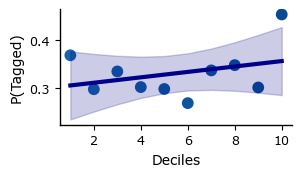

In [6]:
fig,ax=plt.subplots(figsize=(3,1.5))
cmap = mpl.cm.get_cmap('Blues')
colors = np.linspace(.8,.9,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':3,'s':30},ax=ax)
ax.plot(np.arange(1,11),results_run.fittedvalues,'darkblue',linewidth=3,linestyle='-')
# ax.plot(np.arange(1,11),ci_low_run,'--',color='gray',linewidth=2,alpha=.5)
# ax.plot(np.arange(1,11),ci_hi_run,'--',color='gray',linewidth=2,alpha=.5)
ax.fill_between(np.arange(1,11), ci_low_run, ci_hi_run, color='darkblue', alpha=0.2, label='Error Band')  # Error band
sb.despine()
#plt.savefig('run_fc_avmice_regline.svg',transparent=True)

## Figure 2H

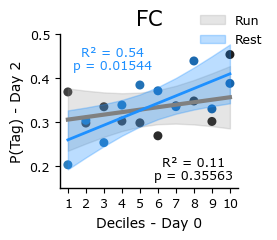

In [7]:
fig,ax=plt.subplots(figsize=(2.3,2))

cmap = mpl.cm.get_cmap('Greys')
colors = np.linspace(.8,.9,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':2,'s':20},ax=ax)
ax.plot(np.arange(1,11),results_run.fittedvalues,'gray',linewidth=3,linestyle='-')
ax.fill_between(np.arange(1,11), ci_low_run, ci_hi_run, color='gray', alpha=0.2, label='Run')  # Error band
sb.despine()
plt.text(8,.2,f"R\u00b2 = {np.round(rsq_run,2)}",ha='center',size=9,color='k')
plt.text(8,.17,f"p = {np.round(pval_run,5):.5f}",ha='center',size=9,color='k')

cmap = mpl.cm.get_cmap('Blues')
colors = np.linspace(.7,.8,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':2,'s':20},ax=ax)
ax.plot(np.arange(1,11),results_rest.fittedvalues,'dodgerblue',linewidth=2,linestyle='-')
ax.fill_between(np.arange(1,11), ci_low_rest, ci_hi_rest, color='dodgerblue', alpha=0.3, label='Rest')  # Error band
plt.ylim([0,.75])

plt.text(3.5,.45,f"R\u00b2 = {np.round(rsq_rest,2)}",ha='center',size=9,color='dodgerblue')
plt.text(3.5,.42,f"p = {np.round(pval_rest,5):.5f}",ha='center',size=9,color='dodgerblue')
plt.title('FC')
plt.ylim([.15,.5])
ax.set_xticks(np.arange(1, 11))
ax.set_xlabel('Deciles - Day 0')
ax.set_ylabel('P(Tag) - Day 2')
plt.legend(bbox_to_anchor=(1.2,1.2),frameon=False,fontsize=9)

plt.savefig(f'Fig3H_rest_run_fc_avmice_regline_overlaid.svg',transparent=True)

# HC MICE

In [8]:
deciles_rest = pd.read_csv('rate_rest_deciles_all.csv')
deciles_rest = deciles_rest.query("Group=='HC'")
deciles_run = pd.read_csv('rate_run_deciles_all.csv')
deciles_run = deciles_run.query("Group=='HC'")

## Figure 2I Stats

In [9]:
Y = [np.mean(deciles_rest['P(Tagged)'].loc[deciles_rest['Deciles']==d].values) for d in np.arange(1,11)]
X = np.arange(0,10)
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results_rest = model.fit()

pred_ols_rest = results_rest.get_prediction()
ci_low_rest = pred_ols_rest.summary_frame()["mean_ci_lower"]
ci_hi_rest = pred_ols_rest.summary_frame()["mean_ci_upper"]
rsq_rest=results_rest.rsquared
pval_rest=results_rest.pvalues[1]
results_rest.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     36.23
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000317
Time:                        15:01:10   Log-Likelihood:                 22.750
No. Observations:                  10   AIC:                            -41.50
Df Residuals:                       8   BIC:                            -40.89
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2134      0.016     13.054      0.000       0.176       0.251
x1             0.0184      0.003      6.019      0.000       0.011       0.025
==============================================================================
Omnibus:                        2.716   Durbin-Watson:                   1.751
Prob(Omnibus):                  0.257   Jarque-Bera (JB):                0.889
Skew:                           0.725   Prob(JB):                        0.641
Kurtosis:                       3.171   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

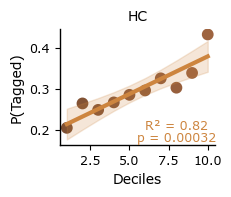

In [10]:
fig,ax=plt.subplots(figsize=(2,1.5))
cmap = mpl.cm.get_cmap('copper')
colors = np.linspace(.4,.5,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':3,'s':30},ax=ax)
ax.plot(np.arange(1,11),results_rest.fittedvalues,'peru',linewidth=3,linestyle='-')
# ax.plot(np.arange(1,11),ci_low_run,'--',color='gray',linewidth=2,alpha=.5)
# ax.plot(np.arange(1,11),ci_hi_run,'--',color='gray',linewidth=2,alpha=.5)
ax.fill_between(np.arange(1,11), ci_low_rest, ci_hi_rest, color='peru', alpha=0.2, label='Error Band')  # Error band
plt.text(8,.2,f"R\u00b2 = {np.round(rsq_rest,2)}",ha='center',size=9,color='peru')
plt.text(8,.17,f"p = {np.round(pval_rest,5):.5f}",ha='center',size=9,color='peru')
plt.title('HC',size=10)
sb.despine()
#plt.savefig('run_hc_avmice_regline.svg',transparent=True)

In [11]:
Y = [np.mean(deciles_run['P(Tagged)'].loc[deciles_run['Deciles']==d].values) for d in np.arange(1,11)]
X = np.arange(0,10)
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results_run = model.fit()

pred_ols = results_run.get_prediction()
ci_low_run = pred_ols.summary_frame()["mean_ci_lower"]
ci_hi_run = pred_ols.summary_frame()["mean_ci_upper"]
rsq_run=results_run.rsquared
pval_run=results_run.pvalues[1]
results_run.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     9.611
Date:                Mon, 04 May 2026   Prob (F-statistic):             0.0147
Time:                        15:01:10   Log-Likelihood:                 20.715
No. Observations:                  10   AIC:                            -37.43
Df Residuals:                       8   BIC:                            -36.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2541      0.020     12.684      0.000       0.208       0.300
x1             0.0116      0.004      3.100      0.015       0.003       0.020
==============================================================================
Omnibus:                        1.203   Durbin-Watson:                   0.685
Prob(Omnibus):                  0.548   Jarque-Bera (JB):                0.723
Skew:                           0.223   Prob(JB):                        0.697
Kurtosis:                       1.761   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

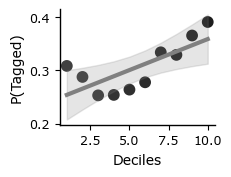

In [12]:
fig,ax=plt.subplots(figsize=(2,1.5))
cmap = mpl.cm.get_cmap('Greys')
colors = np.linspace(.8,.9,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':3,'s':30},ax=ax)
ax.plot(np.arange(1,11),results_run.fittedvalues,'gray',linewidth=3,linestyle='-')
ax.fill_between(np.arange(1,11), ci_low_run, ci_hi_run, color='gray', alpha=0.2, label='Error Band')  # Error band
sb.despine()
#plt.savefig('run_hc_avmice_regline.svg',transparent=True)

## Figure 2I

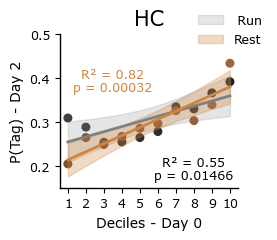

In [13]:
fig,ax=plt.subplots(figsize=(2.3,2))

cmap = mpl.cm.get_cmap('Greys')
colors = np.linspace(.8,.9,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_run,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':2,'s':20},ax=ax)
ax.plot(np.arange(1,11),results_run.fittedvalues,'gray',linewidth=2,linestyle='-')
ax.fill_between(np.arange(1,11), ci_low_run, ci_hi_run, color='gray', alpha=0.2, label=' Run')  # Error band
sb.despine()

plt.text(8,.2,f"R\u00b2 = {np.round(rsq_run,2)}",ha='center',size=9,color='k')
plt.text(8,.17,f"p = {np.round(pval_run,5):.5f}",ha='center',size=9,color='k')

cmap = mpl.cm.get_cmap('copper')
colors = np.linspace(.4,.5,10)
tencolors = [cmap(colors[i]) for i in range(len(colors))]
sb.regplot(data=deciles_rest,x='Deciles',y='P(Tagged)',x_estimator=np.mean,ci=None,fit_reg=False,color='gray',scatter_kws={'alpha':1,'facecolors':tencolors,'edgecolors':tencolors,'linewidths':2,'s':20},ax=ax)
ax.plot(np.arange(1,11),results_rest.fittedvalues,'peru',linewidth=2,linestyle='-')
ax.fill_between(np.arange(1,11), ci_low_rest, ci_hi_rest, color='peru', alpha=0.3, label='Rest')  # Error band
ax.set_xticks(np.arange(1, 11))

plt.text(3.5,.4,f"R\u00b2 = {np.round(rsq_rest,2)}",ha='center',size=9,color='peru')
plt.text(3.5,.37,f"p = {np.round(pval_rest,5):.5f}",ha='center',size=9,color='peru')
plt.title('HC')
plt.ylim([.15,.5])
ax.set_xlabel('Deciles - Day 0')
ax.set_ylabel('P(Tag) - Day 2')
plt.legend(bbox_to_anchor=(1.2,1.2), frameon=False,fontsize=9)
plt.savefig('Fig3I_rest_run_hc_avmice_regline_overlaid.svg',transparent=True)